# HyFlood

! Important: add hydromt in the devcontainer

In [9]:
import os
import os.path as op
import plotly.express as px
import matplotlib.pyplot as plt

In [10]:
root_dir = os.getcwd()

output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

os.makedirs(export_dir, exist_ok=True)

## HyFlood input variables

In [11]:
# Input ranges
variables_bounds = {
    # Ocean forcing
    "Hs_min":  (0.5, 8.0),      # m
    "Hs_max":  (0.5, 8.0),      # m
    "Tp_min":  (5.0, 20.0),     # s
    "Tp_max":  (5.0, 20.0),     # s
    "Dir": (180.0, 330.0),  # deg
    
    "SL":  (-0.5, 2.5),     # m

    # Precipitation forcing
    "A": (0.0, 50.0),
    "D": (1, 48),
    "AMC": (0, 1)
}


In [12]:
variables_bounds.keys()

dict_keys(['Hs_min', 'Hs_max', 'Tp_min', 'Tp_max', 'Dir', 'SL', 'A', 'D', 'AMC'])

## LHS Synthetic Generation

In [13]:
from bluemath_tk.datamining.lhs import LHS

# Generate LHS
lhs = LHS(num_dimensions=len(list(variables_bounds.keys())))

df_dataset = lhs.generate(
    dimensions_names=list(variables_bounds.keys()),
    lower_bounds=[bounds[0] for bounds in variables_bounds.values()],
    upper_bounds=[bounds[1] for bounds in variables_bounds.values()],
    num_samples=10_000,
)

df_dataset

,Hs_min,Hs_max,Tp_min,Tp_max,Dir,SL,A,D,AMC
0,4.353116,2.887287,15.081284,13.100077,260.545323,0.344073,45.055861,30.326077,0.803345
1,1.579979,0.605935,14.555693,17.668505,242.358174,1.323909,45.637733,33.330670,0.402960
2,5.467847,4.135053,18.695374,5.076079,273.802722,1.378006,8.310192,25.549393,0.854646
3,1.390792,5.546630,9.311045,6.005726,284.923262,0.799713,27.681117,22.903819,0.046408
4,7.324220,0.591104,7.765311,11.748406,290.000380,0.610944,27.627035,8.932378,0.519216
...,...,...,...,...,...,...,...,...,...
9995,4.855211,3.378480,15.259471,6.718768,305.703333,-0.487589,35.194807,31.968665,0.801603
9996,5.578999,6.690331,9.509237,13.906461,202.194963,0.920863,48.099129,15.764942,0.960572
9997,3.046965,2.884355,8.393366,7.160942,181.017891,1.147438,48.210407,44.683464,0.338137
9998,6.668468,6.864329,5.487476,15.229947,329.009547,1.267202,2.647628,28.974312,0.471513


## MDA Selection

In [14]:
from bluemath_tk.datamining.mda import MDA

mda_samples = 10

mda = MDA(num_centers=mda_samples)
mda.fit(data=df_dataset, normalize_data=True)

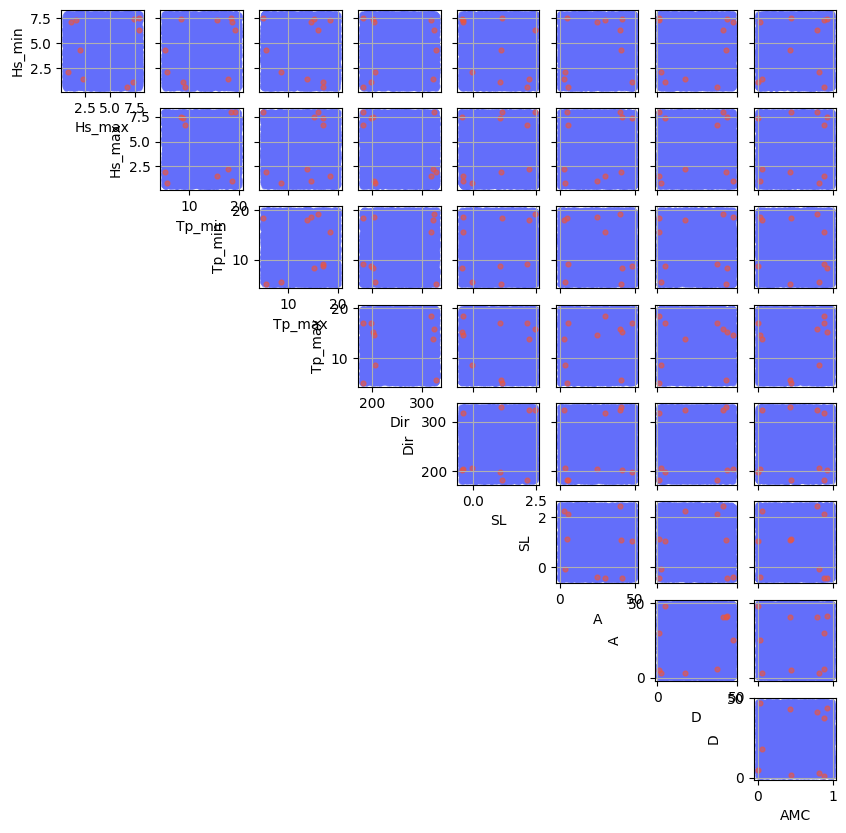

In [15]:
fig, axes = mda.plot_selected_centroids(
    s=12,
    data_color=px.colors.qualitative.Plotly[0],
    centroids_color=px.colors.qualitative.Plotly[1],
)

fig.set_size_inches(10, 10)
plt.show()

## 2. Numerical model: SFINCS

In [16]:
from bluemath_tk.wrappers.sfincs.sfincs_wrapper import SfincsModelWrapper

metamodel_parameters = mda.centroids.to_dict(orient="list")

fixed_parameters = {
    "dxinp": 1,
    "comptime": 300,
    "warmup": 150,
    "n_nodes_per_wavelength": 60,
    "Cf_ini": 100,
    "Cf_fin": 400,
    "Cf": 0.02,
}

sfincs_wrapper = SfincsModelWrapper(
    templates_dir="templates",
    templates_name=["INPUT"],
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
)


2026-09-23 04:04:40,776 - SfincsModelWrapper - WARNING - Parameter Hs_min is not in the default_parameters
2026-09-23 04:04:40,778 - SfincsModelWrapper - WARNING - Parameter Hs_max is not in the default_parameters
2026-09-23 04:04:40,779 - SfincsModelWrapper - WARNING - Parameter Tp_min is not in the default_parameters
2026-09-23 04:04:40,781 - SfincsModelWrapper - WARNING - Parameter Tp_max is not in the default_parameters
2026-09-23 04:04:40,782 - SfincsModelWrapper - WARNING - Parameter Dir is not in the default_parameters
2026-09-23 04:04:40,786 - SfincsModelWrapper - WARNING - Parameter SL is not in the default_parameters
2026-09-23 04:04:40,787 - SfincsModelWrapper - WARNING - Parameter A is not in the default_parameters
2026-09-23 04:04:40,788 - SfincsModelWrapper - WARNING - Parameter D is not in the default_parameters
2026-09-23 04:04:40,790 - SfincsModelWrapper - WARNING - Parameter AMC is not in the default_parameters
